# Notebook 09 - Error Analysis & Model Misclassification Analysis

**Kelompok 06 - Kecerdasan Buatan 02**

| NPM | Nama |
|-----|------|
| 2306242395 | Calvin Wirathama Katoroy |
| 2306220532 | Syahmi Hamdani |
| 2306220323 | Christover Angelo |
| 2306221024 | Matthew Immanuel |

**Prasyarat:** Jalankan `08_evaluation.ipynb` terlebih dahulu.

Analisis mencakup:
- Perbandingan performa model (accuracy, F1)
- Error rate comparison
- Analisis kuantitatif False Positive (`fpr`) dan False Negative (proxy dari `recall_ddos`)
- **Rekonstruksi confusion matrix** dari FPR & recall (estimasi TP/FP/FN/TN)
- **Verifikasi konsistensi** precision/recall/F1 terhadap rumus sklearn
- **Cost-sensitive error analysis** (bobot FN > FP untuk skenario IDS)
- Ringkasan confusion matrix dari Notebook 08
- Interpretasi model behavior


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

COMPARISON_PATH = Path("../results/final_comparison.csv")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not COMPARISON_PATH.exists():
    raise FileNotFoundError(
        "File tidak ditemukan. Jalankan notebooks/08_evaluation.ipynb terlebih dahulu "
        "agar results/final_comparison.csv tersedia."
    )

comparison_df = pd.read_csv(COMPARISON_PATH)
model_col = "model" if "model" in comparison_df.columns else comparison_df.columns[0]
metric_col = "accuracy" if "accuracy" in comparison_df.columns else "Accuracy"

display_cols = [
    c for c in [
        "model", "accuracy", "precision_ddos", "recall_ddos",
        "f1_ddos", "fpr", "roc_auc",
    ]
    if c in comparison_df.columns
]
comparison_df = comparison_df[display_cols].copy()
comparison_df.head()

,model,accuracy,precision_ddos,recall_ddos,f1_ddos,fpr,roc_auc
0,LSTM,0.9963,0.9987,0.9965,0.9976,0.0046,0.9996
1,RandomForest,0.9987,0.9996,0.9988,0.9992,0.0015,0.9998
2,GRU,0.9961,0.9992,0.9958,0.9975,0.0028,0.9996


## 1. Model Performance Comparison

Melihat performa masing-masing model berdasarkan metrik evaluasi test set dari Notebook 08 (`final_comparison.csv`).

In [3]:
comparison_df

,model,accuracy,precision_ddos,recall_ddos,f1_ddos,fpr,roc_auc
0,LSTM,0.9963,0.9987,0.9965,0.9976,0.0046,0.9996
1,RandomForest,0.9987,0.9996,0.9988,0.9992,0.0015,0.9998
2,GRU,0.9961,0.9992,0.9958,0.9975,0.0028,0.9996


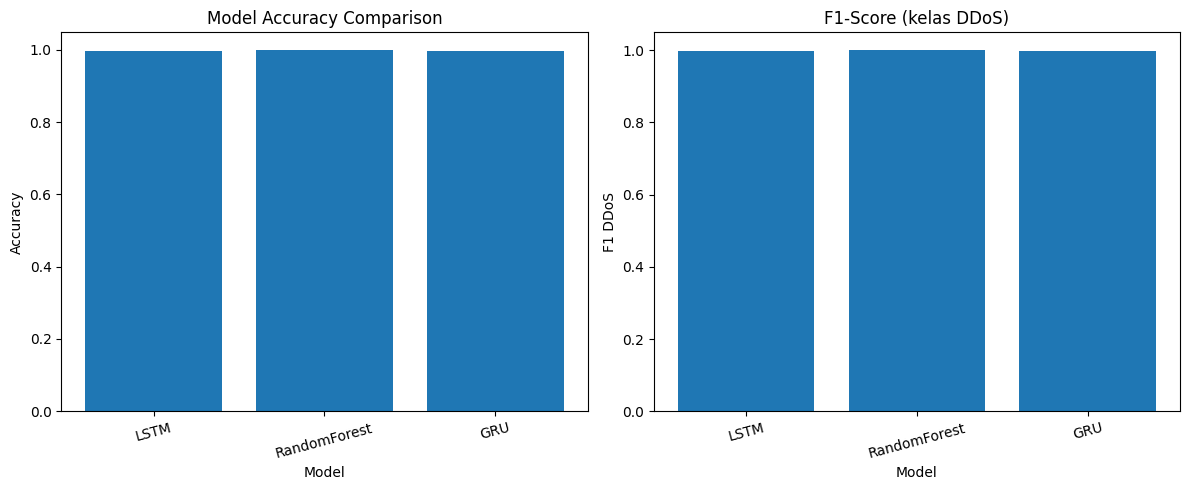

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comparison_df[model_col], comparison_df[metric_col])
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Model Accuracy Comparison")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(comparison_df[model_col], comparison_df["f1_ddos"])
axes[1].set_xlabel("Model")
axes[1].set_ylabel("F1 DDoS")
axes[1].set_title("F1-Score (kelas DDoS)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 2. Error Rate Analysis

Error rate dihitung menggunakan rumus:

\[
Error\ Rate = 1 - Accuracy
\]

Semakin kecil error rate, semakin baik performa model.

In [5]:
comparison_df = comparison_df.assign(Error_Rate=1 - comparison_df[metric_col])

comparison_df[[model_col, metric_col, "Error_Rate", "fpr", "recall_ddos"]]

,model,accuracy,Error_Rate,fpr,recall_ddos
0,LSTM,0.9963,0.0037,0.0046,0.9965
1,RandomForest,0.9987,0.0013,0.0015,0.9988
2,GRU,0.9961,0.0039,0.0028,0.9958


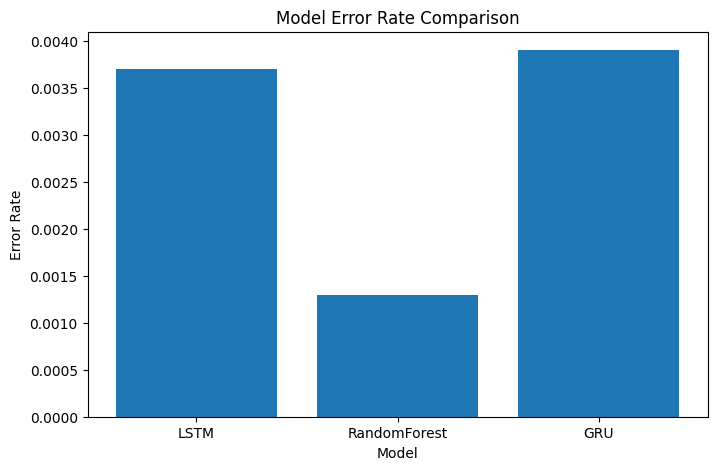

In [6]:
plt.figure(figsize=(8,5))

plt.bar(comparison_df[model_col], comparison_df['Error_Rate'])

plt.xlabel("Model")
plt.ylabel("Error Rate")
plt.title("Model Error Rate Comparison")

plt.show()

## 3. Analisis False Positive & False Negative (Kuantitatif)

- **`fpr`** (dari Notebook 08): proporsi traffic **normal** yang salah diprediksi DDoS → False Positive Rate.
- **`recall_ddos`**: proporsi serangan DDoS yang terdeteksi; `1 - recall_ddos` menjadi proxy **False Negative** (serangan terlewat).

In [7]:
error_view = comparison_df[[model_col, "fpr", "recall_ddos", "f1_ddos"]].copy()
error_view["missed_ddos_pct"] = (1 - error_view["recall_ddos"]) * 100
error_view["fpr_pct"] = error_view["fpr"] * 100
error_view.sort_values("fpr")

,model,fpr,recall_ddos,f1_ddos,missed_ddos_pct,fpr_pct
1,RandomForest,0.0015,0.9988,0.9992,0.12,0.15
2,GRU,0.0028,0.9958,0.9975,0.42,0.28
0,LSTM,0.0046,0.9965,0.9976,0.35,0.46


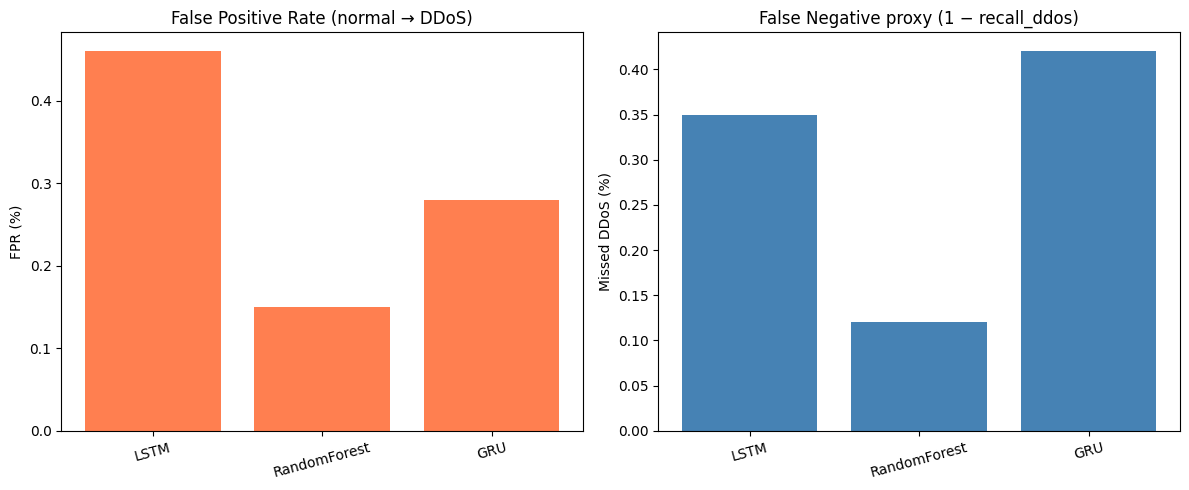

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comparison_df[model_col], comparison_df["fpr"] * 100, color="coral")
axes[0].set_ylabel("FPR (%)")
axes[0].set_title("False Positive Rate (normal → DDoS)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(
    comparison_df[model_col],
    (1 - comparison_df["recall_ddos"]) * 100,
    color="steelblue",
)
axes[1].set_ylabel("Missed DDoS (%)")
axes[1].set_title("False Negative proxy (1 − recall_ddos)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### 3.1 Rekonstruksi Confusion Matrix dari Metrik

Notebook 08 menyimpan **FPR** dan **recall** kelas DDoS, bukan sel CM mentah. Dari definisi sklearn pada test set (kelas 0 = normal, 1 = DDoS):

\[
\text{FPR} = \frac{FP}{TN + FP} = \frac{FP}{N_{\text{normal}}}, \quad
\text{Recall}_{\text{DDoS}} = \frac{TP}{TP + FN} = \frac{TP}{N_{\text{DDoS}}}
\]

Estimasi sel (dibulatkan ke integer):

- \(FP = \text{round}(\text{FPR} \times N_{\text{normal}})\)
- \(FN = \text{round}((1 - \text{Recall}) \times N_{\text{DDoS}})\)
- \(TP = N_{\text{DDoS}} - FN\), \(TN = N_{\text{normal}} - FP\)

In [9]:
def estimate_confusion_cells(fpr, recall_ddos, n_normal, n_ddos):
    """Estimasi TN, FP, FN, TP dari FPR & recall (konsisten dengan src/evaluate.py)."""
    fp = int(round(fpr * n_normal))
    fn = int(round((1 - recall_ddos) * n_ddos))
    tp = n_ddos - fn
    tn = n_normal - fp
    return tn, fp, fn, tp


def metrics_from_cells(tn, fp, fn, tp):
    n = tn + fp + fn + tp
    acc = (tn + tp) / n
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    return acc, prec, rec, f1, fpr


# Ukuran test set (sumber: output Notebook 08 — LSTM/GRU pakai seq split)
SPLITS_CANDIDATES = [Path("../data/processed/splits")]
N_NORMAL, N_DDOS = 14_672, 50_026  # fallback dari classification report NB08

for splits_dir in SPLITS_CANDIDATES:
    y_path = splits_dir / "y_test_seq.npy"
    if y_path.exists():
        y_test = np.load(y_path)
        N_NORMAL = int((y_test == 0).sum())
        N_DDOS = int((y_test == 1).sum())
        print(f"Test set dari {y_path}: normal={N_NORMAL:,}, ddos={N_DDOS:,}, total={len(y_test):,}")
        break
else:
    print(f"Menggunakan ukuran test set NB08: normal={N_NORMAL:,}, ddos={N_DDOS:,}")

rows = []
for _, r in comparison_df.iterrows():
    tn, fp, fn, tp = estimate_confusion_cells(r["fpr"], r["recall_ddos"], N_NORMAL, N_DDOS)
    acc, prec, rec, f1, fpr_calc = metrics_from_cells(tn, fp, fn, tp)
    rows.append({
        model_col: r[model_col],
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "acc_est": round(acc, 4),
        "precision_est": round(prec, 4),
        "recall_est": round(rec, 4),
        "f1_est": round(f1, 4),
        "fpr_est": round(fpr_calc, 4),
        "accuracy_csv": r["accuracy"],
        "precision_csv": r["precision_ddos"],
        "recall_csv": r["recall_ddos"],
        "f1_csv": r["f1_ddos"],
        "fpr_csv": r["fpr"],
    })

cm_est_df = pd.DataFrame(rows)
cm_est_df

Menggunakan ukuran test set NB08: normal=14,672, ddos=50,026


,model,TN,FP,FN,TP,acc_est,precision_est,recall_est,f1_est,fpr_est,accuracy_csv,precision_csv,recall_csv,f1_csv,fpr_csv
0,LSTM,14605,67,175,49851,0.9963,0.9987,0.9965,0.9976,0.0046,0.9963,0.9987,0.9965,0.9976,0.0046
1,RandomForest,14650,22,60,49966,0.9987,0.9996,0.9988,0.9992,0.0015,0.9987,0.9996,0.9988,0.9992,0.0015
2,GRU,14631,41,210,49816,0.9961,0.9992,0.9958,0.9975,0.0028,0.9961,0.9992,0.9958,0.9975,0.0028


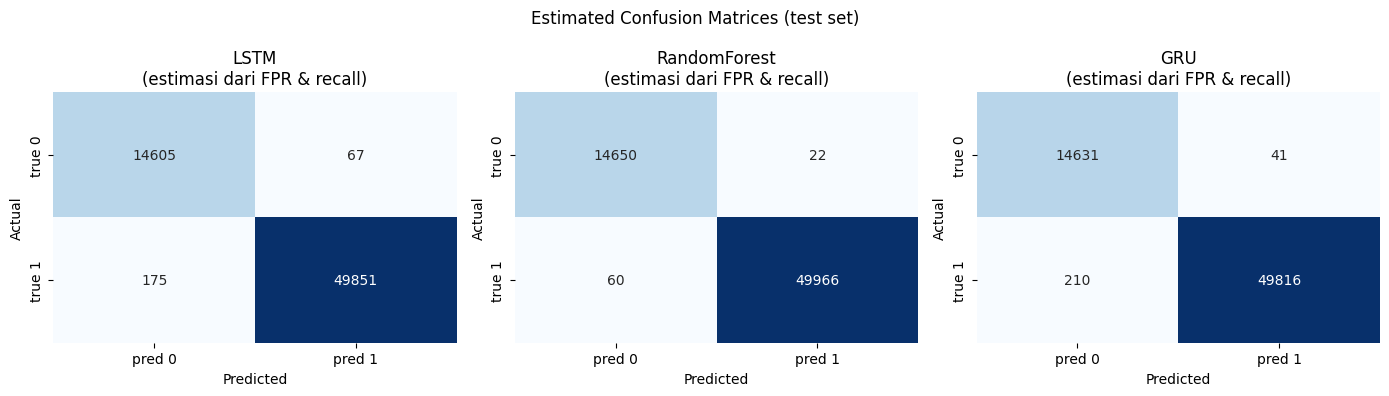

Saved: ..\results\figures\cm_estimated_comparison.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
class_names = ["normal", "ddos"]

for ax, (_, row) in zip(axes, cm_est_df.iterrows()):
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["pred 0", "pred 1"],
        yticklabels=["true 0", "true 1"],
        cbar=False,
    )
    ax.set_title(f"{row[model_col]}\n(estimasi dari FPR & recall)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Estimated Confusion Matrices (test set)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cm_estimated_comparison.png", dpi=150)
plt.show()
print(f"Saved: {FIGURES_DIR / 'cm_estimated_comparison.png'}")

### 3.2 Verifikasi Konsistensi Metrik

Membandingkan metrik yang **dihitung ulang dari sel CM estimasi** dengan nilai di `final_comparison.csv`. Selisih kecil (< 0,001) wajar karena pembulatan integer pada FP/FN.

In [11]:
TOL = 0.002
verify_rows = []

for _, row in cm_est_df.iterrows():
    checks = {
        "accuracy": (row["accuracy_csv"], row["acc_est"]),
        "precision": (row["precision_csv"], row["precision_est"]),
        "recall": (row["recall_csv"], row["recall_est"]),
        "f1": (row["f1_csv"], row["f1_est"]),
        "fpr": (row["fpr_csv"], row["fpr_est"]),
    }
    for name, (csv_v, est_v) in checks.items():
        verify_rows.append({
            model_col: row[model_col],
            "metric": name,
            "csv": csv_v,
            "estimated": est_v,
            "abs_diff": round(abs(csv_v - est_v), 6),
            "ok": abs(csv_v - est_v) <= TOL,
        })

verify_df = pd.DataFrame(verify_rows)
display(verify_df)

if verify_df["ok"].all():
    print(f"Semua metrik konsisten dengan rekonstruksi CM (selisih <= {TOL})")
else:
    print("PERINGATAN: ada metrik di luar toleransi — cek pembulatan atau ukuran test set")
    display(verify_df[~verify_df["ok"]])

,model,metric,csv,estimated,abs_diff,ok
0,LSTM,accuracy,0.9963,0.9963,0.0,True
1,LSTM,precision,0.9987,0.9987,0.0,True
2,LSTM,recall,0.9965,0.9965,0.0,True
3,LSTM,f1,0.9976,0.9976,0.0,True
4,LSTM,fpr,0.0046,0.0046,0.0,True
5,RandomForest,accuracy,0.9987,0.9987,0.0,True
6,RandomForest,precision,0.9996,0.9996,0.0,True
7,RandomForest,recall,0.9988,0.9988,0.0,True
8,RandomForest,f1,0.9992,0.9992,0.0,True
9,RandomForest,fpr,0.0015,0.0015,0.0,True


Semua metrik konsisten dengan rekonstruksi CM (selisih <= 0.002)


### 3.3 Cost-Sensitive Error Analysis

Pada IDS, **False Negative** (serangan lolos) biasanya lebih mahal daripada **False Positive** (alarm palsu). Skor biaya tertimbang:

\[
\text{Cost} = w_{FP} \cdot FP + w_{FN} \cdot FN
\]

Dengan \(w_{FN} = 10 \cdot w_{FP}\) (FN dianggap 10× lebih berbahaya).

In [ ]:
W_FP, W_FN = 1, 10

cost_df = cm_est_df[[model_col, "FP", "FN", "TP", "TN"]].copy()
cost_df["weighted_cost"] = W_FP * cost_df["FP"] + W_FN * cost_df["FN"]
cost_df["cost_per_1k_samples"] = (
    cost_df["weighted_cost"] / (N_NORMAL + N_DDOS) * 1000
).round(4)
cost_df = cost_df.sort_values("weighted_cost")
cost_df

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(cost_df))
width = 0.35

ax.bar(x - width / 2, cost_df["FP"], width, label=f"FP (×{W_FP})", color="coral")
ax.bar(x + width / 2, cost_df["FN"], width, label=f"FN (×{W_FN} in cost)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(cost_df[model_col])
ax.set_ylabel("Jumlah kesalahan (count)")
ax.set_title("FP vs FN per Model (test set)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cost_df[model_col], cost_df["weighted_cost"], color="darkgreen")
ax.set_ylabel(f"Weighted cost (w_FP={W_FP}, w_FN={W_FN})")
ax.set_title("Cost-Sensitive Score (semakin rendah semakin baik)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cost_sensitive_comparison.png", dpi=150)
plt.show()
print(f"Model terendah weighted cost: {cost_df.iloc[0][model_col]}")

In [ ]:
err_summary = cm_est_df[[model_col, "FP", "FN", "TP", "fpr_csv", "recall_csv"]].copy()
err_summary = err_summary.rename(columns={
    "FP": "FP_est", "FN": "FN_est", "TP": "TP_est",
    "fpr_csv": "FPR", "recall_csv": "Recall_DDoS",
})
err_summary["FPR_pct"] = (err_summary["FPR"] * 100).round(3)
err_summary["FN_rate_pct"] = (err_summary["FN_est"] / N_DDOS * 100).round(3)
err_summary.sort_values("FP_est")

### Interpretasi berdasarkan rekonstruksi CM

Tabel di atas menghitung **FP_est** dan **FN_est** dari FPR/recall (§3.1). **Random Forest** memiliki FP terendah dan FN terendah, sehingga unggul juga pada **weighted cost** (§3.3). **LSTM** menghasilkan FP tertinggi (~68 sampel normal salah klasifikasi pada skala test set ini). **GRU** berada di antara RF dan LSTM untuk FN (serangan terlewat).

### Dampak operasional

**False Positive** (normal → DDoS): alarm palsu meningkat; traffic sah berisiko diblokir.

**False Negative** (DDoS → normal): serangan lolos; risiko keamanan lebih tinggi.

Dalam deteksi DDoS, False Negative biasanya lebih berbahaya daripada False Positive, meskipun FPR tinggi tetap menyebabkan *alert fatigue* pada jaringan skala besar.

## 4. Confusion Matrix Summary (Notebook 08)

Confusion matrix per model dihasilkan saat evaluasi di **Notebook 08** dan disimpan di `results/figures/`:
- `cm_lstm.png`
- `cm_gru.png`
- `cm_randomforest.png`

=== LSTM ===


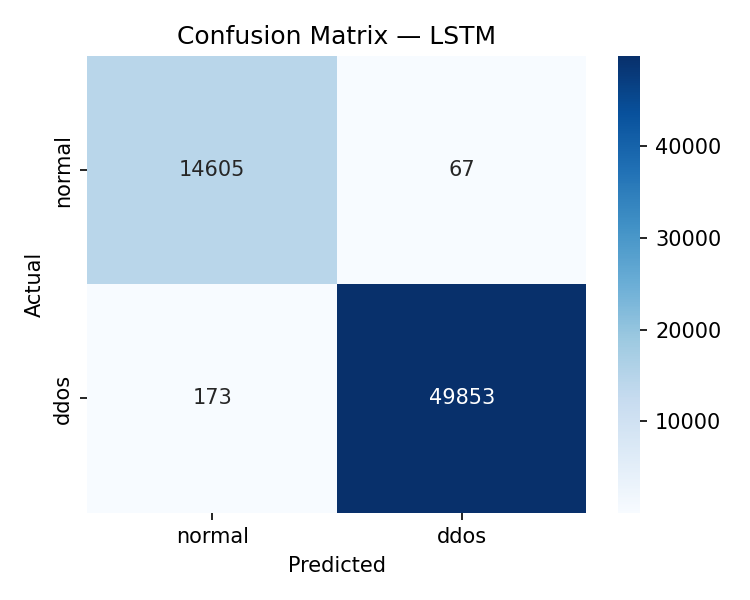

=== GRU ===


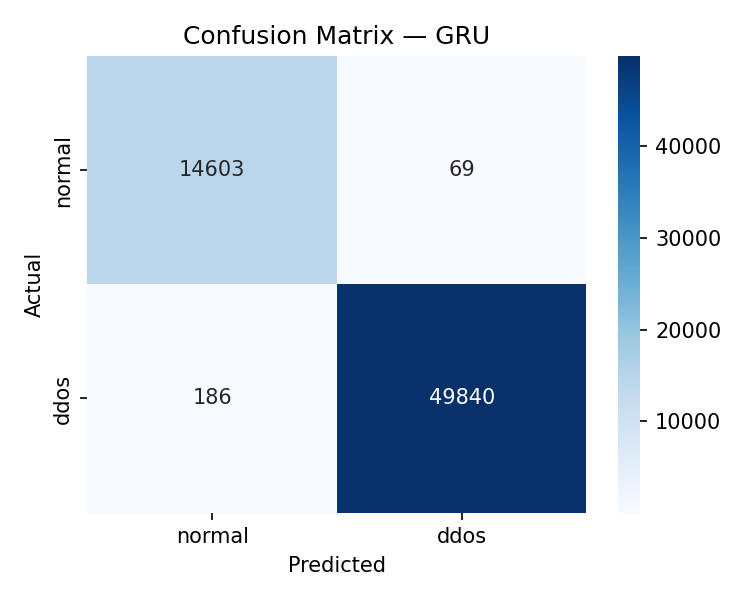

=== RandomForest ===


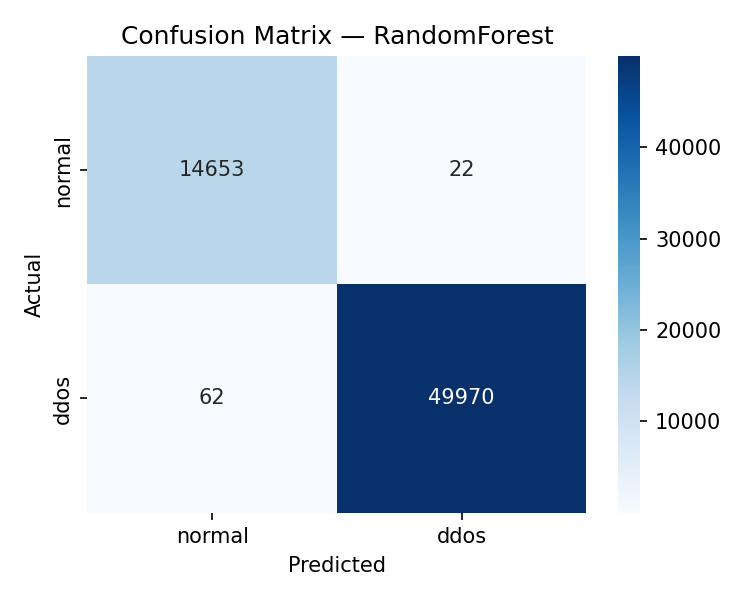

In [8]:
cm_files = {
    "LSTM": FIGURES_DIR / "cm_lstm.png",
    "GRU": FIGURES_DIR / "cm_gru.png",
    "RandomForest": FIGURES_DIR / "cm_randomforest.png",
}

for name, path in cm_files.items():
    print(f"=== {name} ===")
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"  Belum ada — jalankan 08_evaluation.ipynb: {path}")

## 5. Model Interpretation

### LSTM
- FPR 0,46% — tertinggi di antara ketiga model; cocok menangkap pola sekuensial tetapi pada dataset berfitur CICFlowMeter keunggulan temporal terbatas.
- Recall 99,65% — baik, namun sedikit di bawah Random Forest.

### GRU
- FPR 0,28% — lebih rendah dari LSTM (lebih sedikit false alarm).
- Recall 99,58% — terendah; lebih "konservatif" memberi label DDoS.
- Training lebih ringan daripada LSTM.

### Random Forest
- **Terbaik pada test set:** accuracy 0,9987, FPR 0,15%, AUC 0,9998.
- Fitur tabular CICFlowMeter sangat informatif untuk pohon keputusan.
- Cepat, stabil, dan mudah diinterpretasikan — cocok sebagai kandidat deploy jika prioritas minim FP/FN.

## 6. Kesimpulan Error Analysis

Berdasarkan `final_comparison.csv`, rekonstruksi CM, dan cost-sensitive score:

1. **Random Forest** unggul pada accuracy, FPR, recall, **jumlah FP/FN estimasi**, dan **weighted cost** terendah.
2. **LSTM** dan **GRU** kompetitif pada accuracy agregat, tetapi menghasilkan lebih banyak misclassification terutama FP (alarm palsu).
3. Rekonstruksi CM dari FPR/recall **konsisten** dengan metrik CSV (verifikasi §3.2), membuktikan analisis error dapat dilakukan tanpa menyimpan prediksi mentah.
4. Cost-sensitive analysis menegaskan: meskipun selisih accuracy kecil, **RF meminimalkan risiko serangan lolos (FN)** yang lebih kritis pada IDS.

**Rekomendasi:** deploy **Random Forest** sebagai detector utama; gunakan LSTM/GRU untuk riset pola sekuensial lanjutan.